In [ ]:
!pip install pandas numpy
!pip install nltk
!pip install plotly
!pip install wordcloud
!pip install -U sentence-transformers

!pip install scikit-learn

In [ ]:
!pip install contractions
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# 1- Import data from a website using the requests library and format it as a reusable DataFrame.

In [ ]:
import requests
import pandas as pd
def extract_all_data():
    x=["1000","2000","3000","4000","5500"]
    data= ""
    for x_i in x:
        data += requests.get(f'https://cogcomp.seas.upenn.edu/Data/QA/QC/train_{x_i}.label').text
        data += "\n"
    data_list=data.split("\n")
    data_json = {
        "target" : [],
        "question" : []
    }
    for d in data_list :
        try:
          if(len(d) > 0) :
            index = d.index(':') #The index() method in Python is used to find the first occurrence of a specified value within a string
            label, question = d[:index],d[index+1:]
            data_json["target"].append(label)
            data_json["question"].append(question)
        except:
            print(d)
    return data_json


train_data=pd.DataFrame(extract_all_data())


# Exploration

In [ ]:
train_data.head()


,target,question
0,DESC,manner How did serfdom develop in and then lea...
1,ENTY,cremat What films featured the character Popey...
2,DESC,manner How can I find a list of celebrities ' ...
3,ENTY,animal What fowl grabs the spotlight after the...
4,ABBR,exp What is the full form of .com ?


In [ ]:
list( train_data["target"].unique() )


['DESC', 'ENTY', 'ABBR', 'HUM', 'NUM', 'LOC']

# 2 -Data Preprocessing

In [ ]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
from sentence_transformers import SentenceTransformer
from nltk.stem import WordNetLemmatizer
import re
import string
import inflect
import contractions
p_inf = inflect.engine()
tokens = word_tokenize(" Hello word i am his bitch ")
stop_words = set(stopwords.words('english'))
p = PorterStemmer()
def convert_number(text):
    tokens = word_tokenize(text)
    for i in range(len(tokens)):
        if(tokens[i].isdigit()):
            tokens[i] = p_inf.number_to_words(tokens[i])
    return " ".join(tokens)
def remove_punctuation(text):
    translator= str.maketrans('','',string.punctuation)
    return text.translate(translator)
# methode to clean text

def preprocess_text (text):

    """
    Clean, tokenize, and stem the input text.

    Steps:
    - Convert to lowercase
    - Remove extra whitespace
    - Convert numbers to words
    - Remove punctuation
    - Remove stopwords
    - Apply stemming
    """
    #Text Lowercase
    text = text.lower()
    ##don't to do not
    text = contractions.fix(text)
    ## special characters
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # remove whitespace from text
    text = " ".join(text.split())
    # convert numbers to text
    text = convert_number(text)
    # remove punctuation
    text = remove_punctuation(text)
    # Apply stemming
    text= " ".join( [w for w in word_tokenize(text) if w not in stop_words ])
    return  " ".join([ p.stem(w) for w in word_tokenize(text) ] )

input_text = "Hello world! I am excited to learn text preprocessing."
cleaned_text = preprocess_text(input_text)
print(cleaned_text)



hello world excit learn text preprocess


In [ ]:

questions = train_data.question.str.cat(sep = ' ')
tokens = word_tokenize(preprocess_text(questions))
tokens = [w for w in tokens ]
vocabulary = set(tokens)
frequency_dist = nltk.FreqDist(tokens)
#sorted(frequency_dist,key=frequency_dist.__getitem__, reverse=True)[0:50]

# 3 - Data Visulizations

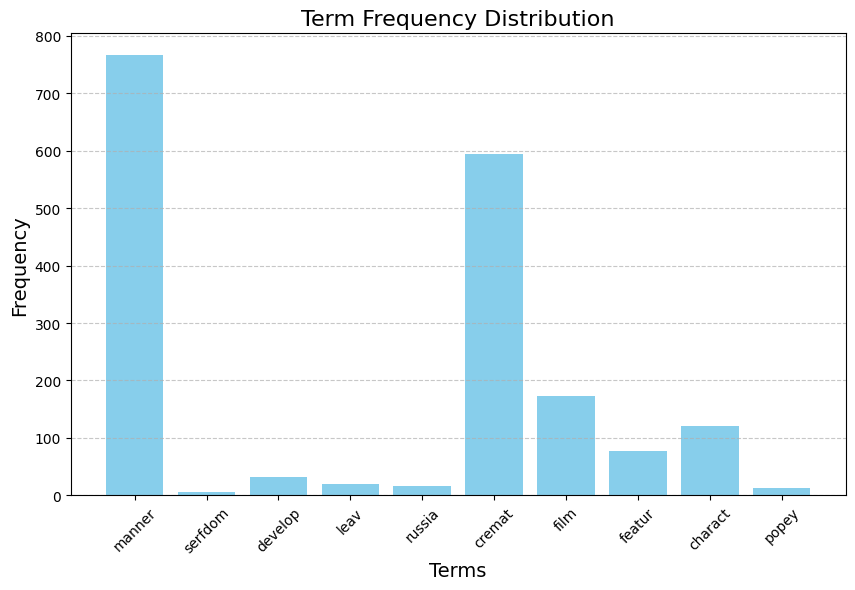

In [ ]:
import matplotlib.pyplot as plt

terms = list(frequency_dist.keys())[0:10]
frequencies = list(frequency_dist.values())[0:10]

# Bar chart
plt.figure(figsize=(10, 6))
plt.bar(terms, frequencies, color='skyblue')
plt.xlabel("Terms", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.title("Term Frequency Distribution", fontsize=16)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

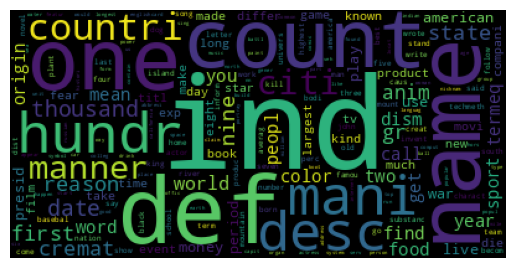

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
wordcloud = WordCloud().generate_from_frequencies(frequency_dist)
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

# 4 - Transform Data into usefull Representation


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
label_encoder = preprocessing.LabelEncoder()
X,y = train_data.question,label_encoder.fit_transform(train_data.target)
(X_train, X_test, y_train, y_test) = train_test_split(X, y,test_size = .2,random_state = 22)


In [ ]:
def get_corpus(X):
     corpus = list(X)
     vocabulary = set(corpus)

     new_corpus = []
     for c in corpus :
        new_corpus.append(preprocess_text(c))
     return new_corpus
corpus_train=get_corpus(X_train)
corpus_test = get_corpus(X_test)


In [ ]:
#from sklearn.feature_extraction.text import TfidfTransformer
#from sklearn.feature_extraction.text import TfidfVectorizer
model = SentenceTransformer("all-MiniLM-L6-v2")

#vectorizer = TfidfVectorizer()
#train_vectors = vectorizer.fit_transform(X_train)
#test_vectors = vectorizer.transform(X_test)
train_model_data = model.encode(corpus_train)
test_model_data = model.encode(corpus_test)
print(train_model_data.shape, test_model_data.shape)

(12361, 384) (3091, 384)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
train_model_data = torch.tensor(train_model_data,dtype=torch.float32)
y_train = torch.tensor(y_train,dtype=torch.long)
y_test = torch.tensor(y_test,dtype=torch.long)

test_model_data = torch.tensor(test_model_data,dtype=torch.float32)


In [ ]:
import torch
import torch.nn as nn

class QuestionClassificationModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=2, dropout=0):
        super(QuestionClassificationModel, self).__init__()

        # LSTM Layer
        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )

        # Fully Connected Layer
        self.fc = nn.Linear(hidden_size * 2, output_size)  # *2 for bidirectional LSTM

    def forward(self, x):
        # LSTM Forward Pass
        lstm_out, _ = self.lstm(x)

        # Use the last hidden state for classification
        out = self.fc(lstm_out[:, -1, :])  # Last hidden state

        return out

# Hyperparameters
input_size = train_model_data.shape[1]  # Embedding size
hidden_size = 128  # Number of features in hidden state
output_size = len(label_encoder.classes_)  # Number of classes
num_layers =  2 # Stack 2 LSTM layers
dropout = 0  # Dropout for regularization
learning_rate = 0.001
num_epochs = 50

# Initialize model, loss, and optimizer
model_lstm = QuestionClassificationModel(input_size, hidden_size, output_size, num_layers, dropout)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=learning_rate)

# Convert data to appropriate shape
train_model_data = train_model_data.unsqueeze(1)  # Add sequence length dimension
test_model_data = test_model_data.unsqueeze(1)

# Train the LSTM model
for epoch in range(num_epochs):
    # Forward pass
    outputs = model_lstm(train_model_data)
    loss = criterion(outputs, y_train.long())  # Ensure y_train is of type Long

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# Evaluate the model
with torch.no_grad():
    y_pred = model_lstm(test_model_data)
    y_pred_classes = torch.argmax(y_pred, dim=1)
    accuracy = (y_pred_classes == y_test).float().mean()
    print(f"Test Accuracy: {accuracy:.4f}")


Epoch [1/50], Loss: 1.7828
Epoch [2/50], Loss: 1.7783
Epoch [3/50], Loss: 1.7738
Epoch [4/50], Loss: 1.7693
Epoch [5/50], Loss: 1.7646
Epoch [6/50], Loss: 1.7598
Epoch [7/50], Loss: 1.7548
Epoch [8/50], Loss: 1.7494
Epoch [9/50], Loss: 1.7437
Epoch [10/50], Loss: 1.7376
Epoch [11/50], Loss: 1.7311
Epoch [12/50], Loss: 1.7241
Epoch [13/50], Loss: 1.7166
Epoch [14/50], Loss: 1.7086
Epoch [15/50], Loss: 1.7001
Epoch [16/50], Loss: 1.6911
Epoch [17/50], Loss: 1.6816
Epoch [18/50], Loss: 1.6717
Epoch [19/50], Loss: 1.6615
Epoch [20/50], Loss: 1.6509
Epoch [21/50], Loss: 1.6402
Epoch [22/50], Loss: 1.6293
Epoch [23/50], Loss: 1.6182
Epoch [24/50], Loss: 1.6070
Epoch [25/50], Loss: 1.5956
Epoch [26/50], Loss: 1.5838
Epoch [27/50], Loss: 1.5716
Epoch [28/50], Loss: 1.5588
Epoch [29/50], Loss: 1.5454
Epoch [30/50], Loss: 1.5312
Epoch [31/50], Loss: 1.5160
Epoch [32/50], Loss: 1.4999
Epoch [33/50], Loss: 1.4827
Epoch [34/50], Loss: 1.4643
Epoch [35/50], Loss: 1.4445
Epoch [36/50], Loss: 1.4233
E

In [ ]:
import torch
import torch.nn as nn

class QuestionClassificationModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout=0.3):
        super(QuestionClassificationModel, self).__init__()

        # Fully connected layers
        self.lin1 = nn.Linear(input_size, hidden_size)  # input_size should be 384 based on your input data
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.lin2 = nn.Linear(hidden_size, output_size)  # output_size is number of classes
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.lin1(x)
        x = self.relu(x)
        x = self.dropout(x)  # Apply dropout
        x = self.lin2(x)
        x = self.softmax(x)  # Softmax for multi-class classification
        return x

# Hyperparameters
input_size = train_model_data.shape[1]  # Embedding size (should be 384 for "all-MiniLM-L6-v2" model)
hidden_size = 128  # Number of features in hidden state
output_size = len(label_encoder.classes_)  # Number of classes (the number of question types)
dropout = 0.3  # Dropout for regularization
learning_rate = 0.001
num_epochs = 50



# Initialize model, loss, and optimizer
model = QuestionClassificationModel(input_size, hidden_size, output_size, dropout)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Train the model
for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    # Forward pass
    outputs = model(train_model_data)  # No need for unsqueeze
    loss = criterion(outputs, y_train)

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# Evaluate the model
model.eval()  # Set model to evaluation mode
with torch.no_grad():
    y_pred = model(test_model_data)  # No need for unsqueeze
    y_pred_classes = torch.argmax(y_pred, dim=1)
    accuracy = (y_pred_classes == y_test).float().mean()
    print(f"Test Accuracy: {accuracy:.4f}")


Epoch [1/50], Loss: 1.7908
Epoch [2/50], Loss: 1.7897
Epoch [3/50], Loss: 1.7886
Epoch [4/50], Loss: 1.7875
Epoch [5/50], Loss: 1.7863
Epoch [6/50], Loss: 1.7851
Epoch [7/50], Loss: 1.7838
Epoch [8/50], Loss: 1.7825
Epoch [9/50], Loss: 1.7811
Epoch [10/50], Loss: 1.7797
Epoch [11/50], Loss: 1.7781
Epoch [12/50], Loss: 1.7763
Epoch [13/50], Loss: 1.7746
Epoch [14/50], Loss: 1.7726
Epoch [15/50], Loss: 1.7706
Epoch [16/50], Loss: 1.7684
Epoch [17/50], Loss: 1.7662
Epoch [18/50], Loss: 1.7638
Epoch [19/50], Loss: 1.7613
Epoch [20/50], Loss: 1.7586
Epoch [21/50], Loss: 1.7559
Epoch [22/50], Loss: 1.7529
Epoch [23/50], Loss: 1.7498
Epoch [24/50], Loss: 1.7468
Epoch [25/50], Loss: 1.7432
Epoch [26/50], Loss: 1.7397
Epoch [27/50], Loss: 1.7365
Epoch [28/50], Loss: 1.7322
Epoch [29/50], Loss: 1.7284
Epoch [30/50], Loss: 1.7242
Epoch [31/50], Loss: 1.7201
Epoch [32/50], Loss: 1.7156
Epoch [33/50], Loss: 1.7109
Epoch [34/50], Loss: 1.7058
Epoch [35/50], Loss: 1.7010
Epoch [36/50], Loss: 1.6960
E

In [ ]:
import torch
import torch.nn as nn

class QuestionClassificationModelGRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=2, dropout=0):
        super(QuestionClassificationModelGRU, self).__init__()

        # GRU Layer
        self.gru = nn.GRU(
            input_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True  # Bidirectional GRU
        )

        # Fully Connected Layer
        self.fc = nn.Linear(hidden_size * 2, output_size)  # *2 for bidirectional GRU

    def forward(self, x):
        # GRU Forward Pass
        gru_out, _ = self.gru(x)

        # Use the last hidden state for classification
        out = self.fc(gru_out[:, -1, :])  # Last hidden state

        return out

# Hyperparameters
input_size = 384  # Size of the embeddings from SentenceTransformer
hidden_size = 128  # Number of features in hidden state
output_size = len(label_encoder.classes_)  # Number of classes
num_layers = 3
dropout = 0  # Dropout for regularization
learning_rate = 0.001
num_epochs = 50

# Initialize model, loss, and optimizer
model_gru = QuestionClassificationModelGRU(input_size, hidden_size, output_size, num_layers, dropout)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_gru.parameters(), lr=learning_rate)

# Convert data to appropriate shape
train_model_data = torch.tensor(train_model_data, dtype=torch.float32).unsqueeze(1)  # Add sequence length dimension (batch, seq_len, input_size)
test_model_data = torch.tensor(test_model_data, dtype=torch.float32).unsqueeze(1)   # Add sequence length dimension

# Train the GRU model
for epoch in range(num_epochs):
    # Forward pass
    outputs = model_gru(train_model_data)
    loss = criterion(outputs, y_train.long())  # Ensure y_train is of type Long

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# Evaluate the model
with torch.no_grad():
    y_pred = model_gru(test_model_data)
    y_pred_classes = torch.argmax(y_pred, dim=1)
    accuracy = (y_pred_classes == y_test).float().mean()
    print(f"Test Accuracy: {accuracy:.4f}")

<ipython-input-39-fff35f7f41bc>:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_model_data = torch.tensor(train_model_data, dtype=torch.float32).unsqueeze(1)  # Add sequence length dimension (batch, seq_len, input_size)
<ipython-input-39-fff35f7f41bc>:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_model_data = torch.tensor(test_model_data, dtype=torch.float32).unsqueeze(1)   # Add sequence length dimension


Epoch [1/50], Loss: 1.7934
Epoch [2/50], Loss: 1.7807
Epoch [3/50], Loss: 1.7686
Epoch [4/50], Loss: 1.7567
Epoch [5/50], Loss: 1.7444
Epoch [6/50], Loss: 1.7315
Epoch [7/50], Loss: 1.7178
Epoch [8/50], Loss: 1.7033
Epoch [9/50], Loss: 1.6880
Epoch [10/50], Loss: 1.6724
Epoch [11/50], Loss: 1.6571
Epoch [12/50], Loss: 1.6425
Epoch [13/50], Loss: 1.6292
Epoch [14/50], Loss: 1.6168
Epoch [15/50], Loss: 1.6046
Epoch [16/50], Loss: 1.5918
Epoch [17/50], Loss: 1.5783
Epoch [18/50], Loss: 1.5642
Epoch [19/50], Loss: 1.5489
Epoch [20/50], Loss: 1.5309
Epoch [21/50], Loss: 1.5088
Epoch [22/50], Loss: 1.4819
Epoch [23/50], Loss: 1.4504
Epoch [24/50], Loss: 1.4145
Epoch [25/50], Loss: 1.3741
Epoch [26/50], Loss: 1.3293
Epoch [27/50], Loss: 1.2804
Epoch [28/50], Loss: 1.2285
Epoch [29/50], Loss: 1.1753
Epoch [30/50], Loss: 1.1216
Epoch [31/50], Loss: 1.0680
Epoch [32/50], Loss: 1.0147
Epoch [33/50], Loss: 0.9624
Epoch [34/50], Loss: 0.9122
Epoch [35/50], Loss: 0.8648
Epoch [36/50], Loss: 0.8206
E